# EDA â€” Panel Ãºnico Bloomberg Â· figuras que complementan los resultados del CapÃ­tulo 2

Base: `bbg/Panel_bloomberg.csv` (13 economÃ­as, EMBI Global Diversified + JLoss + GaR).
Adapta las figuras de la SecciÃ³n 14 de `EDA_Panel_Final_17.ipynb` (base `all17`, superada) a
la base Bloomberg y a la **orientaciÃ³n `D = âˆ’GaR`** (riesgo de cola; `D` mayor = peor), de
modo que el coeficiente de interacciÃ³n **Î²â‚ƒ = coef(`JLoss Ã— D`) = âˆ’Î¸** sale **positivo
cuando hay amplificaciÃ³n**.

Salida: `bbg/figuras/eda_*.png` y `.pdf`. Paleta y estilo compartidos con `p4_figuras.py`.

In [1]:
import os, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

BBG = "C:/Users/HOME/Claude/proyects/Jloss/1_Codigo/Panel/bbg"
FIG = os.path.join(BBG, "figuras"); os.makedirs(FIG, exist_ok=True)
PANEL_CSV = os.path.join(BBG, "Panel_bloomberg.csv")

# paleta validada (data-viz skill), igual que p4_figuras.py
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, INK2, SURF, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e7e6e2"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.linewidth": 0.8,
    "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

CTRLS = ["debt_gdp", "fisc_bal", "res_gdp", "ca_gdp", "infl_yoy", "reer"]
CRISIS_Q = (["2008Q4"] + [f"2009Q{k}" for k in (1, 2, 3, 4)]
            + [f"2020Q{k}" for k in (1, 2, 3, 4)] + [f"2021Q{k}" for k in (1, 2, 3, 4)])

def load_panel():
    d = pd.read_csv(PANEL_CSV)
    d = d.dropna(subset=["EMBI_bps", "JLoss", "GaR"]).copy()
    d["GaR_pp"] = d["GaR"] * 100.0
    d["D_pp"]   = -d["GaR_pp"]                       # D = -GaR : riesgo de cola
    d["t"]      = pd.PeriodIndex(d["quarter"], freq="Q").to_timestamp()
    d["year"]   = pd.PeriodIndex(d["quarter"], freq="Q").year
    d["sin_crisis"] = ~d["quarter"].isin(CRISIS_Q)
    return d

def fit_M(d, ctrls=CTRLS, interaction=True):
    # M2 de la tesis: JLoss + D + (JLoss x D) + 6 controles, FE pais+tiempo, DK
    cc = [c for c in ctrls if c in d.columns and d[c].notna().sum() > 50]
    dd = d.dropna(subset=["EMBI_bps", "JLoss", "D_pp"] + cc).copy()
    dd["JLoss_c"] = dd["JLoss"] - dd["JLoss"].mean()
    dd["D_c"]     = dd["D_pp"]  - dd["D_pp"].mean()
    dd["JxD"]     = dd["JLoss_c"] * dd["D_c"]
    rhs = ["JLoss_c", "D_c"] + (["JxD"] if interaction else []) + cc
    f = "EMBI_bps ~ " + " + ".join(rhs) + " + EntityEffects + TimeEffects"
    m = PanelOLS.from_formula(f, dd.set_index(["country", "t"])).fit(
        cov_type="kernel", kernel="bartlett")
    return m, dd

def save(fig, name):
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIG, name + "." + ext), dpi=150, bbox_inches="tight")
    print("  ->", name)

dat = load_panel()
print("Panel: N=%d  paises=%d  %s..%s" % (len(dat), dat.country.nunique(),
                                          dat.quarter.min(), dat.quarter.max()))
m2, dd2 = fit_M(dat)
b1, bD, b3 = m2.params["JLoss_c"], m2.params["D_c"], m2.params["JxD"]
print("M2  b1(JLoss)=%+.2f  coef(D)=%+.2f  b3(JLoss x D)=%+.3f  (t=%+.2f, p=%.3f)  N=%d"
      % (b1, bD, b3, m2.tstats["JxD"], m2.pvalues["JxD"], int(m2.nobs)))

Panel: N=721  paises=13  2004Q1..2026Q1
M2  b1(JLoss)=+2.77  coef(D)=+4.56  b3(JLoss x D)=+0.188  (t=+1.18, p=0.239)  N=614


## 1 Â· Cobertura del panel (muestra de estimaciÃ³n)

  -> eda_01_cobertura


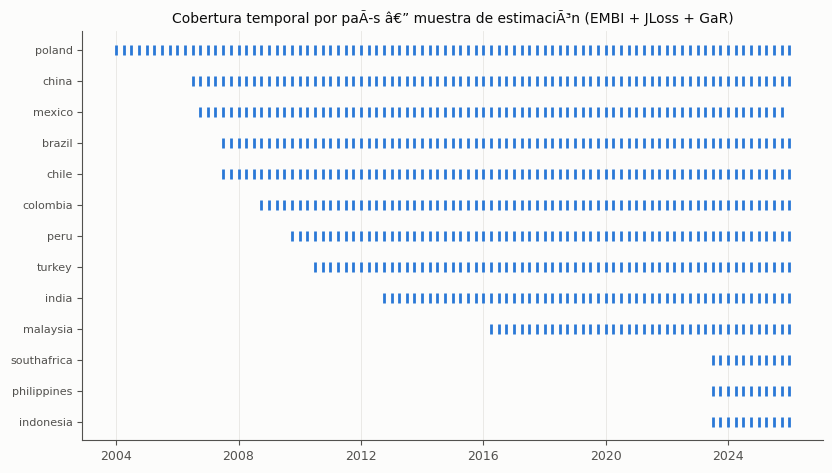

In [2]:
order = dat.groupby("country")["EMBI_bps"].count().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(8.4, 4.8))
for i, c in enumerate(order):
    g = dat[dat.country == c]
    ax.plot(g["t"], [i] * len(g), "|", color=BLUE, ms=7, mew=2)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.grid(axis="y", visible=False)
ax.set_title("Cobertura temporal por paÃ­s â€” muestra de estimaciÃ³n (EMBI + JLoss + GaR)")
save(fig, "eda_01_cobertura"); plt.show()

## 2 Â· Superficie de complementariedad, con dimensiÃ³n temporal

El "mapa" que discutiÃ³ Juan: iso-curvas del spread predicho por los efectos condicionales de
`JLoss` y `D`. Cuanto mÃ¡s se doblan hacia la esquina "alta fragilidad + cola severa", mÃ¡s
fuerte la amplificaciÃ³n supra-aditiva (Î²â‚ƒ > 0). **Puntos coloreados por aÃ±o**: observaciones
recientes oscuras, antiguas claras â€” para separar el pasado del presente.

  -> eda_02_superficie_temporal


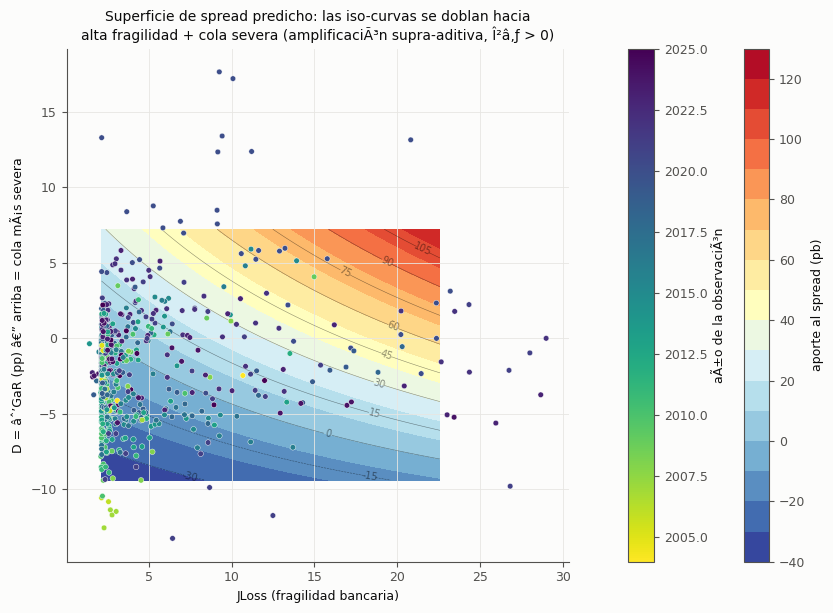

In [3]:
muJ, muD = dd2["JLoss"].mean(), dd2["D_pp"].mean()
jg = np.linspace(dd2["JLoss"].quantile(.02), dd2["JLoss"].quantile(.98), 140)
dg = np.linspace(dd2["D_pp"].quantile(.02),  dd2["D_pp"].quantile(.98),  140)
JJ, DD = np.meshgrid(jg, dg)
S = b1 * (JJ - muJ) + bD * (DD - muD) + b3 * ((JJ - muJ) * (DD - muD))

fig, ax = plt.subplots(figsize=(8.8, 6.2))
cf = ax.contourf(JJ, DD, S, levels=18, cmap="RdYlBu_r")
cs = ax.contour(JJ, DD, S, levels=10, colors="k", linewidths=.4, alpha=.45)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
sc = ax.scatter(dd2["JLoss"], dd2["D_pp"], c=dd2["year"], cmap="viridis_r",
                s=16, edgecolor="white", linewidth=.3, zorder=5)
ax.set_xlabel("JLoss (fragilidad bancaria)")
ax.set_ylabel("D = âˆ’GaR (pp) â€” arriba = cola mÃ¡s severa")
ax.set_title("Superficie de spread predicho: las iso-curvas se doblan hacia\n"
             "alta fragilidad + cola severa (amplificaciÃ³n supra-aditiva, Î²â‚ƒ > 0)")
fig.colorbar(cf, ax=ax, label="aporte al spread (pb)", pad=0.02)
fig.colorbar(sc, ax=ax, label="aÃ±o de la observaciÃ³n", pad=0.09)
save(fig, "eda_02_superficie_temporal"); plt.show()

## 3 Â· Efecto marginal âˆ‚EMBI/âˆ‚JLoss segÃºn el riesgo de cola â€” completa vs. sin crisis

  -> eda_03_efecto_marginal


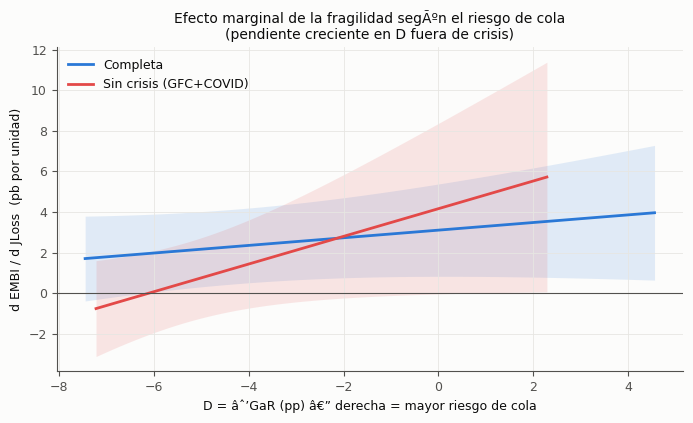

In [4]:
def marginal(d, ctrls=CTRLS):
    m, dd = fit_M(d, ctrls)
    V = m.cov
    grid = np.linspace(dd["D_pp"].quantile(.05), dd["D_pp"].quantile(.95), 80)
    dev  = grid - dd["D_pp"].mean()
    me   = m.params["JLoss_c"] + m.params["JxD"] * dev
    se   = np.sqrt(V.loc["JLoss_c", "JLoss_c"] + dev**2 * V.loc["JxD", "JxD"]
                   + 2 * dev * V.loc["JLoss_c", "JxD"])
    return grid, me, se

fig, ax = plt.subplots(figsize=(7, 4.3))
for d, lab, col in [(dat, "Completa", BLUE),
                    (dat[dat.sin_crisis], "Sin crisis (GFC+COVID)", RED)]:
    g, me, se = marginal(d)
    ax.fill_between(g, me - 1.96 * se, me + 1.96 * se, color=col, alpha=.13, lw=0)
    ax.plot(g, me, color=col, lw=2, label=lab)
ax.axhline(0, color=INK2, lw=.8)
ax.set_xlabel("D = âˆ’GaR (pp) â€” derecha = mayor riesgo de cola")
ax.set_ylabel("d EMBI / d JLoss  (pb por unidad)")
ax.set_title("Efecto marginal de la fragilidad segÃºn el riesgo de cola\n"
             "(pendiente creciente en D fuera de crisis)")
ax.legend(loc="upper left")
save(fig, "eda_03_efecto_marginal"); plt.show()

## 4 Â· Binscatter: la pendiente JLossâ†’EMBI se empina en cola severa

  -> eda_04_binscatter_regimen


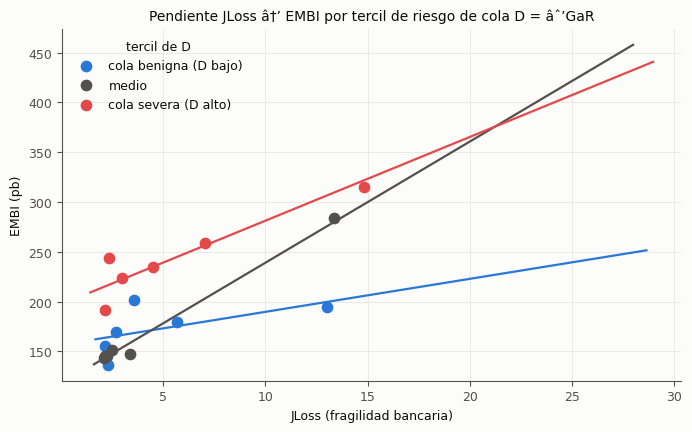

In [5]:
d = dd2.copy()
d["terc"] = pd.qcut(d["D_pp"], 3, labels=["cola benigna (D bajo)", "medio", "cola severa (D alto)"])
pal = {"cola benigna (D bajo)": BLUE, "medio": INK2, "cola severa (D alto)": RED}
fig, ax = plt.subplots(figsize=(7, 4.4))
for terc, g in d.groupby("terc"):
    g = g.copy()
    g["bin"] = pd.qcut(g["JLoss"], min(6, g["JLoss"].nunique()), duplicates="drop")
    bs = g.groupby("bin").agg(J=("JLoss", "mean"), E=("EMBI_bps", "mean"))
    ax.scatter(bs["J"], bs["E"], color=pal[terc], s=55, zorder=4, label=str(terc))
    a, b = np.polyfit(g["JLoss"], g["EMBI_bps"], 1)
    xs = np.array([g["JLoss"].min(), g["JLoss"].max()])
    ax.plot(xs, a * xs + b, color=pal[terc], lw=1.6)
ax.set_xlabel("JLoss (fragilidad bancaria)"); ax.set_ylabel("EMBI (pb)")
ax.set_title("Pendiente JLoss â†’ EMBI por tercil de riesgo de cola D = âˆ’GaR")
ax.legend(title="tercil de D")
save(fig, "eda_04_binscatter_regimen"); plt.show()

## 5 Â· JLoss vs EMBI, coloreado por tercil de D

  -> eda_05_complementariedad


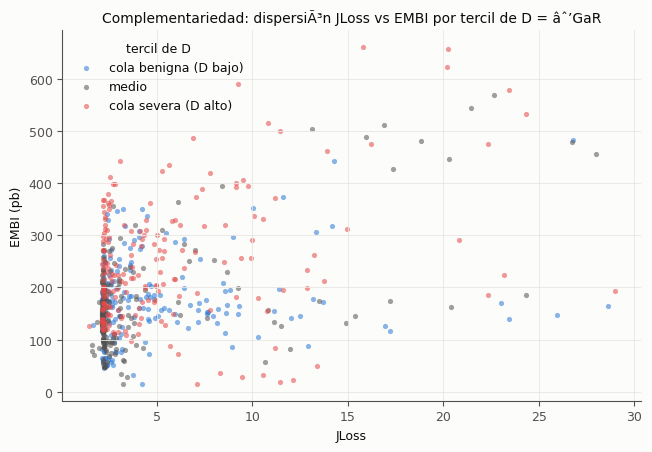

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for terc, g in d.groupby("terc"):
    ax.scatter(g["JLoss"], g["EMBI_bps"], color=pal[terc], s=14, alpha=.55, lw=0, label=str(terc))
ax.set_xlabel("JLoss"); ax.set_ylabel("EMBI (pb)")
ax.set_title("Complementariedad: dispersiÃ³n JLoss vs EMBI por tercil de D = âˆ’GaR")
ax.legend(title="tercil de D")
save(fig, "eda_05_complementariedad"); plt.show()

## 6 Â· Prima de amplificaciÃ³n Î²â‚ƒÂ·(JLoss_c Â· D_c) por paÃ­s

Puntos base de spread que **aÃ±ade la complementariedad** por encima de los efectos lineales
de `JLoss` y `D`. Mediana y rango intercuartÃ­lico por paÃ­s.

  -> eda_06_prima_amplificacion


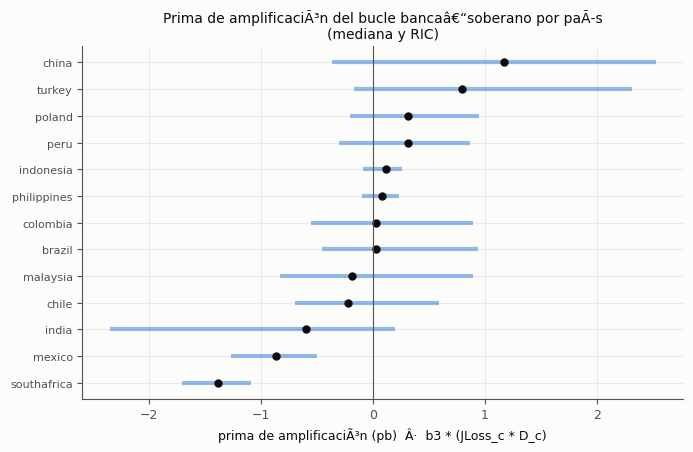

In [7]:
d2 = dd2.copy()
d2["amp"] = b3 * d2["JLoss_c"] * d2["D_c"]
by = d2.groupby("country")["amp"].agg(med="median",
                                      q25=lambda x: x.quantile(.25),
                                      q75=lambda x: x.quantile(.75)).sort_values("med")
fig, ax = plt.subplots(figsize=(7, 4.6))
y = np.arange(len(by))
ax.hlines(y, by["q25"], by["q75"], color=BLUE, lw=3, alpha=.5)
ax.plot(by["med"], y, "o", color=INK, ms=5)
ax.axvline(0, color=INK2, lw=.8)
ax.set_yticks(y); ax.set_yticklabels(by.index, fontsize=8)
ax.set_xlabel("prima de amplificaciÃ³n (pb)  Â·  b3 * (JLoss_c * D_c)")
ax.set_title("Prima de amplificaciÃ³n del bucle bancaâ€“soberano por paÃ­s\n(mediana y RIC)")
save(fig, "eda_06_prima_amplificacion"); plt.show()

## 7 Â· Leave-one-country-out de Î²â‚ƒ

  -> eda_07_leave_one_out


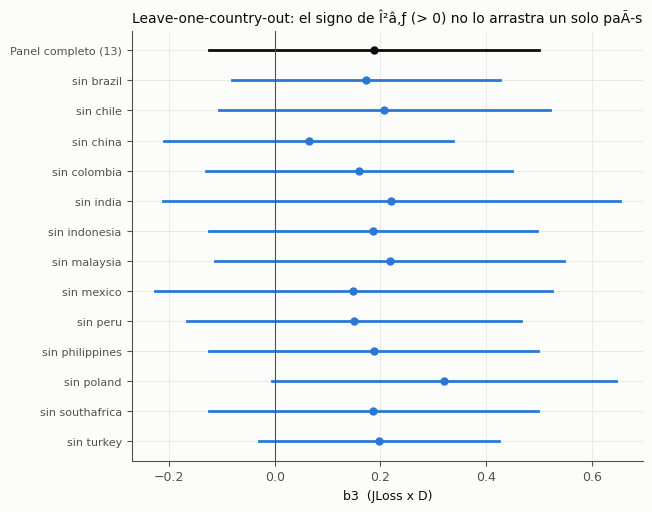

In [8]:
rows = [("Panel completo (13)", b3, m2.std_errors["JxD"])]
for c in sorted(dat.country.unique()):
    mc, _ = fit_M(dat[dat.country != c])
    rows.append(("sin " + c, mc.params["JxD"], mc.std_errors["JxD"]))
rows = rows[::-1]
fig, ax = plt.subplots(figsize=(6.6, 5.2))
for i, (lab, est, se) in enumerate(rows):
    col = INK if lab.startswith("Panel") else BLUE
    ax.plot([est - 1.96 * se, est + 1.96 * se], [i, i], color=col, lw=2)
    ax.plot(est, i, "o", color=col, ms=5, zorder=5)
ax.axvline(0, color=INK2, lw=.8)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=8)
ax.set_xlabel("b3  (JLoss x D)")
ax.set_title("Leave-one-country-out: el signo de Î²â‚ƒ (> 0) no lo arrastra un solo paÃ­s")
save(fig, "eda_07_leave_one_out"); plt.show()

## 8 Â· InteracciÃ³n de crisis â€” sin botar trimestres

En vez de estimar el efecto "sin crisis" **botando** los trimestres de crisis, se mantiene
toda la muestra y se interactÃºa la complementariedad con un vector de crisis (indicaciÃ³n del
profesor coguÃ­a):

$$\text{EMBI}_{it}=\alpha_i+\delta_t+\beta_1 JLoss_{it}+\beta_2 D_{it}+\beta_3 (JLoss\times D)_{it}
+\beta_4 (JLoss\times D\times \text{Crisis})_{it}+\beta_5 (JLoss\times\text{Crisis})_{it}+\beta_6 (D\times\text{Crisis})_{it}+\omega'X_{it}+\varepsilon_{it}$$

- $\beta_3$ = complementariedad **fuera** de crisis; $\beta_3+\beta_4$ = **en** crisis.
- PredicciÃ³n del coguÃ­a: $\beta_4\approx-\beta_3\Rightarrow\beta_3+\beta_4\approx0$ (los
  respaldos oficiales desacoplan el canal domÃ©stico en crisis).
- ($\text{Crisis}$ sola es *time-varying* â†’ la absorben los efectos fijos de tiempo.)

**DescomposiciÃ³n (el test de falsaciÃ³n):** se separa el vector en `Backstop` (GFC 2008Q4â€“2009Q4
+ COVID 2020Q1â€“2021Q4, con respaldos Fed/FMI/QE masivos) y `EMstress` (2015Q3â€“2016Q1, sin
respaldos). El mecanismo predice que la complementariedad **se anula bajo `Backstop`** pero
**no bajo `EMstress`**.

Fuente de verdad: `bbg/p9_crisis_interaccion.py` (Python) y `bbg/crisis_interaccion.R` (R) â€”
los coeficientes coinciden a 4 decimales. Este notebook reproduce la spec de referencia (FE
paÃ­s+tiempo, +6 controles).


=== Vector Ãºnico de crisis (companion) ===   N=614
  Î²â‚ƒ (fuera de crisis)   = +0.811  (t=+1.96, p=0.051)
  Î²â‚„ Ã— Crisis             = -0.839  (t=-1.96, p=0.050)
  Î²â‚ƒ + Î²â‚„ (Crisis)         = -0.028  â†’  Wald Hâ‚€: Î²â‚ƒ+Î²â‚„=0  p=0.766   (no rechaza: se anula)

=== Backstop vs EMstress (headline â€” test de falsaciÃ³n) ===   N=614
  Î²â‚ƒ (fuera de crisis)   = +0.837  (t=+2.02, p=0.044)
  Î²â‚„ Ã— Backstop           = -0.942  (t=-2.23, p=0.026)
  Î²â‚ƒ + Î²â‚„ (Backstop)         = -0.105  â†’  Wald Hâ‚€: Î²â‚ƒ+Î²â‚„=0  p=0.270   (no rechaza: se anula)
  Î²â‚„ Ã— EMstress           = +0.213  (t=+0.43, p=0.669)
  Î²â‚ƒ + Î²â‚„ (EMstress)         = +1.051  â†’  Wald Hâ‚€: Î²â‚ƒ+Î²â‚„=0  p=0.000   (rechaza: sigue presente)


  -> eda_08_efecto_marginal_regimen


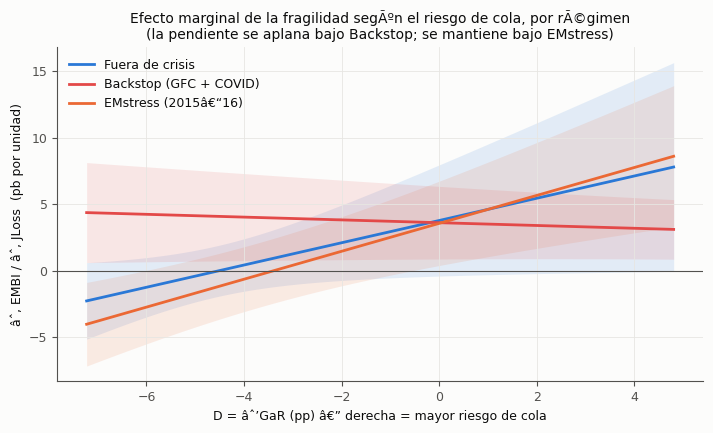

In [9]:
from scipy import stats

GFC      = ["2008Q4", "2009Q1", "2009Q2", "2009Q3", "2009Q4"]
COVID    = ["2020Q1", "2020Q2", "2020Q3", "2020Q4", "2021Q1", "2021Q2", "2021Q3", "2021Q4"]
EM1516   = ["2015Q3", "2015Q4", "2016Q1"]           # estrÃ©s EM 2015-16 (ajustable)
CRISIS   = GFC + COVID + EM1516
BACKSTOP = GFC + COVID


def fit_crisis(d, dummies, ctrls=CTRLS):
    """dummies: dict nombre -> lista de quarters. FE paÃ­s+tiempo, DK."""
    cc = [c for c in ctrls if c in d.columns and d[c].notna().sum() > 50]
    dd = d.dropna(subset=["EMBI_bps", "JLoss", "D_pp"] + cc).copy()
    dd["JLoss_c"] = dd["JLoss"] - dd["JLoss"].mean()
    dd["D_c"]     = dd["D_pp"]  - dd["D_pp"].mean()
    dd["JxD"]     = dd["JLoss_c"] * dd["D_c"]
    rhs = ["JLoss_c", "D_c", "JxD"]
    for nm, qs in dummies.items():
        cr = dd["quarter"].isin(qs).astype(float)
        dd[f"JxD_{nm}"], dd[f"JLoss_{nm}"], dd[f"D_{nm}"] = (
            dd["JxD"] * cr, dd["JLoss_c"] * cr, dd["D_c"] * cr)
        rhs += [f"JxD_{nm}", f"JLoss_{nm}", f"D_{nm}"]
    rhs += cc
    f = "EMBI_bps ~ " + " + ".join(rhs) + " + EntityEffects + TimeEffects"
    m = PanelOLS.from_formula(f, dd.set_index(["country", "t"])).fit(
        cov_type="kernel", kernel="bartlett")
    return m


def lincom(m, names):
    """coef, se, p de la suma de varios parÃ¡metros (delta method)."""
    b = float(sum(m.params[n] for n in names))
    V = m.cov
    se = float(np.sqrt(sum(V.loc[i, j] for i in names for j in names)))
    p = 2 * (1 - stats.norm.cdf(abs(b / se)))
    return b, se, p


for titulo, dummies in [("Vector Ãºnico de crisis (companion)", {"cr": CRISIS}),
                        ("Backstop vs EMstress (headline â€” test de falsaciÃ³n)",
                         {"bk": BACKSTOP, "em": EM1516})]:
    m = fit_crisis(dat, dummies)
    b3 = m.params["JxD"]
    print(f"\n=== {titulo} ===   N={int(m.nobs)}")
    print(f"  Î²â‚ƒ (fuera de crisis)   = {b3:+.3f}  (t={m.tstats['JxD']:+.2f}, p={m.pvalues['JxD']:.3f})")
    for nm in dummies:
        lbl = {"cr": "Crisis", "bk": "Backstop", "em": "EMstress"}[nm]
        b4 = m.params[f"JxD_{nm}"]
        sb, _, sp = lincom(m, ["JxD", f"JxD_{nm}"])
        print(f"  Î²â‚„ Ã— {lbl:9s}          = {b4:+.3f}  (t={m.tstats[f'JxD_{nm}']:+.2f}, "
              f"p={m.pvalues[f'JxD_{nm}']:.3f})")
        print(f"  Î²â‚ƒ + Î²â‚„ ({lbl})         = {sb:+.3f}  â†’  Wald Hâ‚€: Î²â‚ƒ+Î²â‚„=0  p={sp:.3f}"
              f"   {'(no rechaza: se anula)' if sp > .10 else '(rechaza: sigue presente)'}")

# --- figura: efecto marginal âˆ‚EMBI/âˆ‚JLoss vs D, por rÃ©gimen ---
mB = fit_crisis(dat, {"bk": BACKSTOP, "em": EM1516})
V = mB.cov
Dbar = dat["D_pp"].mean()
grid = np.linspace(dat["D_pp"].quantile(.05), dat["D_pp"].quantile(.95), 80)
dev = grid - Dbar

# por rÃ©gimen: lista de (piezas de nivel, piezas de interacciÃ³n)
regimenes = [
    ("Fuera de crisis",         ["JLoss_c"],              ["JxD"],            BLUE),
    ("Backstop (GFC + COVID)",   ["JLoss_c", "JLoss_bk"],  ["JxD", "JxD_bk"],  RED),
    ("EMstress (2015â€“16)",       ["JLoss_c", "JLoss_em"],  ["JxD", "JxD_em"],  ORANGE),
]
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for lab, lvl, itr, col in regimenes:
    me = sum(mB.params[p] for p in lvl) + sum(mB.params[p] for p in itr) * dev
    # se(me) punto a punto: a = 1 en piezas de nivel, dev en piezas de interacciÃ³n
    se = np.array([
        np.sqrt(
            sum(V.loc[i, j] for i in lvl for j in lvl)
            + 2 * dv * sum(V.loc[i, j] for i in lvl for j in itr)
            + dv**2 * sum(V.loc[i, j] for i in itr for j in itr)
        ) for dv in dev
    ])
    ax.fill_between(grid, me - 1.96 * se, me + 1.96 * se, color=col, alpha=.12, lw=0)
    ax.plot(grid, me, color=col, lw=2, label=lab)
ax.axhline(0, color=INK2, lw=.8)
ax.set_xlabel("D = âˆ’GaR (pp) â€” derecha = mayor riesgo de cola")
ax.set_ylabel("âˆ‚ EMBI / âˆ‚ JLoss  (pb por unidad)")
ax.set_title("Efecto marginal de la fragilidad segÃºn el riesgo de cola, por rÃ©gimen\n"
             "(la pendiente se aplana bajo Backstop; se mantiene bajo EMstress)")
ax.legend(loc="upper left")
save(fig, "eda_08_efecto_marginal_regimen"); plt.show()

---
*Trazabilidad:* Î²â‚ƒ = âˆ’Î¸; los nÃºmeros de referencia estÃ¡n en `bbg/NUMEROS_CANONICOS_BBG.md`
y `bbg/bateria_bbg.csv` (forma `Î¸`). Las figuras "oficiales" de la tesis las genera
`bbg/p4_figuras.py`; este notebook es material complementario de EDA.